In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, mean_absolute_error
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import os
import time
from datetime import timedelta
import sys
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [3]:
class CEFRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx]) - 1

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# С1 и С2 по отдельности

In [4]:
df = pd.read_csv('ru_cefr_short.csv')
df['label'] = df['textbook-assigned cefr level'].astype(int)
df

,fragment,textbook-assigned cefr level,label
0,"Весной, летом и осенью почти каждую субботу он...",1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1
2,На каждой двери красные плакаты и красные фона...,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1
...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,6
7320,Mapillary использует программное обеспечение д...,6,6


In [5]:
model_start_time = time.time()
model_name = 'ai-forever/sbert_large_nlu_ru'
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6,
    id2label={0: 'A1', 1: 'A2', 2: 'B1', 3: 'B2', 4: 'C1', 5: 'C2'},
    label2id={'A1': 0, 'A2': 1, 'B1': 2, 'B2': 3, 'C1': 4, 'C2': 5}
)

model = model.to(device)
print(f"Модель инициализирована")

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/863 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai-forever/sbert_large_nlu_ru and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована


In [6]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_dataset = CEFRDataset(train_texts, train_labels, tokenizer)
val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)


print(f"Обучающая выборка: {len(train_texts)}")
print(f"Валидационная выборка: {len(val_texts)}")

Обучающая выборка: 5857
Валидационная выборка: 1465


In [7]:
training_args = TrainingArguments(
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    learning_rate=2e-5
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

In [8]:
train_start_time = time.time()
trainer.train()
train_time = time.time() - train_start_time
print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

Epoch,Training Loss,Validation Loss
1,1.020100,0.953472
2,0.525300,0.955287
3,0.177500,1.523963
4,0.030200,1.980187
5,0.009100,2.093954


Обучение завершено за 536.10 секунд (0:08:56)


In [9]:
def evaluate_model(model, val_dataset, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for i in range(len(val_dataset)):
            batch = val_dataset[i]
            
            inputs = {
                'input_ids': batch['input_ids'].unsqueeze(0).to(device),
                'attention_mask': batch['attention_mask'].unsqueeze(0).to(device)
            }
            
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            predictions.append(pred + 1)  
            true_labels.append(batch['labels'].item() + 1)  

    return true_labels, predictions


true_labels, predictions = evaluate_model(model, val_dataset, device)

In [10]:
accuracy = accuracy_score(true_labels, predictions)
f1_micro = f1_score(true_labels, predictions, average="micro")
f1_macro = f1_score(true_labels, predictions, average="macro")
f1_weighted = f1_score(true_labels, predictions, average="weighted")
mae = mean_absolute_error(true_labels, predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"MAE: {mae:.4f}")

Accuracy: 0.6253
F1 Micro: 0.6253
F1 Macro: 0.5295
F1 Weighted: 0.6188
MAE: 0.4601


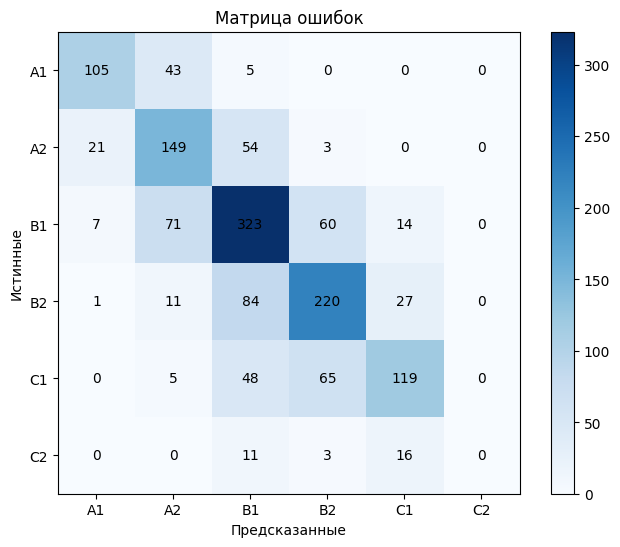

In [11]:
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title('Матрица ошибок')
plt.colorbar(im)
plt.show()

In [12]:
print(f"{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")

0.6253
0.6253
0.5295
0.6188
0.4601
536.10


# Объединенные С1 и С2

In [13]:
df = pd.read_csv('ru_cefr_short.csv')
df['label'] = df['textbook-assigned cefr level'].astype(int)
df['label'] = df['label'].replace(6, 5)
df

,fragment,textbook-assigned cefr level,label
0,"Весной, летом и осенью почти каждую субботу он...",1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1
2,На каждой двери красные плакаты и красные фона...,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1
...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,5
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,5
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,5
7320,Mapillary использует программное обеспечение д...,6,5


In [14]:
model_start_time = time.time()
model_name = 'ai-forever/sbert_large_nlu_ru'
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=5,
    id2label={0: 'A1', 1: 'A2', 2: 'B1', 3: 'B2', 4: 'C1'},
    label2id={'A1': 0, 'A2': 1, 'B1': 2, 'B2': 3, 'C1': 4}
)

model = model.to(device)
print(f"Модель инициализирована")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai-forever/sbert_large_nlu_ru and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована


In [15]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_dataset = CEFRDataset(train_texts, train_labels, tokenizer)
val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)


print(f"Обучающая выборка: {len(train_texts)}")
print(f"Валидационная выборка: {len(val_texts)}")

Обучающая выборка: 5857
Валидационная выборка: 1465


In [16]:
training_args = TrainingArguments(
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    learning_rate=2e-5
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

In [17]:
train_start_time = time.time()
trainer.train()
train_time = time.time() - train_start_time
print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

Epoch,Training Loss,Validation Loss
1,0.912200,0.905542
2,0.529400,0.924506
3,0.167200,1.545206
4,0.037200,1.940541
5,0.019400,2.084247


Обучение завершено за 536.88 секунд (0:08:56)


In [18]:
def evaluate_model(model, val_dataset, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for i in range(len(val_dataset)):
            batch = val_dataset[i]
            
            inputs = {
                'input_ids': batch['input_ids'].unsqueeze(0).to(device),
                'attention_mask': batch['attention_mask'].unsqueeze(0).to(device)
            }
            
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            predictions.append(pred + 1)  
            true_labels.append(batch['labels'].item() + 1)  

    return true_labels, predictions


true_labels, predictions = evaluate_model(model, val_dataset, device)

In [19]:
accuracy = accuracy_score(true_labels, predictions)
f1_micro = f1_score(true_labels, predictions, average="micro")
f1_macro = f1_score(true_labels, predictions, average="macro")
f1_weighted = f1_score(true_labels, predictions, average="weighted")
mae = mean_absolute_error(true_labels, predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"MAE: {mae:.4f}")

Accuracy: 0.6430
F1 Micro: 0.6430
F1 Macro: 0.6461
F1 Weighted: 0.6389
MAE: 0.4307


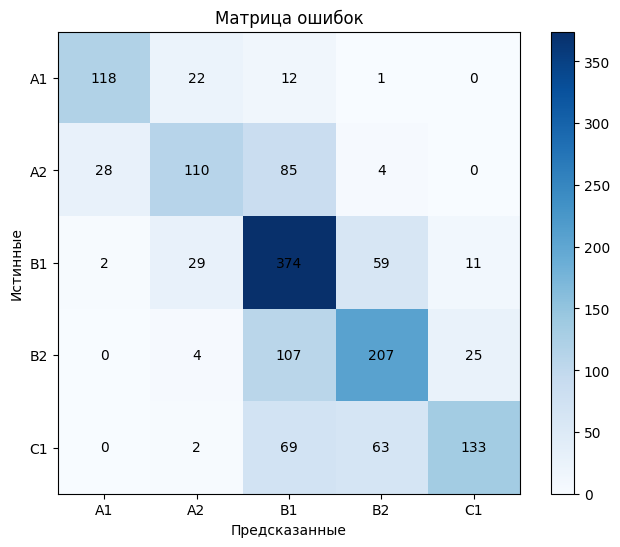

In [20]:
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title('Матрица ошибок')
plt.colorbar(im)
plt.show()

In [21]:
print(f"{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")

0.6430
0.6430
0.6461
0.6389
0.4307
536.88
